# Код для 10 гипотез улучшения baseline

Этот ноутбук — готовый каркас для запуска 10 экспериментов поверх baseline.
Он построен так, чтобы:
- переиспользовать общие функции подготовки данных;
- запускать гипотезы независимо;
- сравнивать их по `WAPE + |Relative Bias|`;
- при желании переводить прогноз в количество машин.

> Ноутбук рассчитан на данные и baseline из соревнования по прогнозу отгрузок.

In [1]:

from __future__ import annotations

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Iterable

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False
    CatBoostRegressor = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Конфиг
Проверь пути к файлам. По умолчанию я использую те же имена, что и в baseline.

In [6]:

CONFIG = {
    "train_path": "Dd2WPGKz/train_team_track.parquet",   # замени при необходимости
    "test_path": "Dd2WPGKz/test_team_track.parquet",     # замени при необходимости
    "forecast_points": 10,                     # 10 шагов по 30 минут = 5 часов
    "time_col": "timestamp",
    "target_col": "target_2h",
    "route_col": "route_id",
    "office_col": "office_from_id",
    "id_col": "id",
    "step_minutes": 30,
    "valid_ratio": 0.2,
    "max_train_rows": None,                    # например 500_000 при нехватке памяти
}

FORECAST_POINTS = CONFIG["forecast_points"]
TIME_COL = CONFIG["time_col"]
TARGET_COL = CONFIG["target_col"]
ROUTE_COL = CONFIG["route_col"]
OFFICE_COL = CONFIG["office_col"]
ID_COL = CONFIG["id_col"]
STEP_MINUTES = CONFIG["step_minutes"]
FUTURE_TARGET_COLS = [f"target_step_{i}" for i in range(1, FORECAST_POINTS + 1)]

## 2. Загрузка данных

In [7]:

train_path = Path(CONFIG["train_path"])
test_path = Path(CONFIG["test_path"])

if train_path.exists():
    train_df = pd.read_parquet(train_path)
    train_df[TIME_COL] = pd.to_datetime(train_df[TIME_COL])
    train_df = train_df.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
    print("train shape:", train_df.shape)
    print(train_df.head())
else:
    raise FileNotFoundError(f"Не найден файл train: {train_path}")

if test_path.exists():
    test_df = pd.read_parquet(test_path)
    test_df[TIME_COL] = pd.to_datetime(test_df[TIME_COL])
    test_df = test_df.sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)
    print("test shape:", test_df.shape)
    print(test_df.head())
else:
    test_df = None
    print("test file не найден — это нормально, если ты сейчас только валидируешь гипотезы.")

train shape: (4342000, 12)
   office_from_id  route_id           timestamp  status_1  status_2  status_3  status_4  status_5  status_6  status_7  status_8  target_2h
0              26         0 2025-03-01 00:00:00         0        46         0         0        12         9         0         0       79.0
1              26         0 2025-03-01 00:30:00         0        34         0         0        16         0       187         0       88.0
2              26         0 2025-03-01 01:00:00         0        19         0         0        31         0         0         0       88.0
3              26         0 2025-03-01 01:30:00         0        33         0         0        36       129         0         0       88.0
4              26         0 2025-03-01 02:00:00         0        24         0         0        55        12         0         0      103.0
test shape: (10000, 3)
     id  route_id           timestamp
0  4900         0 2025-05-30 11:00:00
1  4901         0 2025-05-30 11:30:00
2 

## 3. Базовые списки признаков и метрика

In [8]:

status_cols = sorted([c for c in train_df.columns if c.startswith("status_")])

class WapePlusRbias:
    @property
    def name(self) -> str:
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        denom = np.maximum(y_true.sum(), 1e-9)
        wape = np.abs(y_pred - y_true).sum() / denom
        rbias = abs(y_pred.sum() / denom - 1.0)
        return float(wape + rbias)

metric = WapePlusRbias()

def evaluate_predictions(y_true: pd.DataFrame, y_pred: pd.DataFrame, prefix: str = "") -> pd.DataFrame:
    rows = []
    total_score = metric.calculate(y_true.values, y_pred.values)
    rows.append({"horizon": "all", "metric": total_score})

    for col in y_true.columns:
        rows.append({"horizon": col, "metric": metric.calculate(y_true[col].values, y_pred[col].values)})

    out = pd.DataFrame(rows)
    if prefix:
        out.insert(0, "experiment", prefix)
    return out

## 4. Подготовка supervised-таблицы как в baseline

In [9]:

def make_future_targets(df: pd.DataFrame, route_col: str = ROUTE_COL, target_col: str = TARGET_COL, horizon: int = FORECAST_POINTS) -> pd.DataFrame:
    df = df.copy()
    grp = df.groupby(route_col, sort=False)
    for step in range(1, horizon + 1):
        df[f"target_step_{step}"] = grp[target_col].shift(-step)
    return df

train_supervised = make_future_targets(train_df)
supervised_df = train_supervised.dropna(subset=FUTURE_TARGET_COLS).copy()

print("supervised shape:", supervised_df.shape)
supervised_df[[ROUTE_COL, TIME_COL, TARGET_COL] + FUTURE_TARGET_COLS[:3]].head()

supervised shape: (4332000, 22)


,route_id,timestamp,target_2h,target_step_1,target_step_2,target_step_3
0,0,2025-03-01 00:00:00,79.0,88.0,88.0,88.0
1,0,2025-03-01 00:30:00,88.0,88.0,88.0,103.0
2,0,2025-03-01 01:00:00,88.0,88.0,103.0,94.0
3,0,2025-03-01 01:30:00,88.0,103.0,94.0,106.0
4,0,2025-03-01 02:00:00,103.0,94.0,106.0,127.0


## 5. Функции feature engineering

Ниже — общий набор функций, из которого собираются все 10 гипотез.

In [10]:

def add_time_features(df: pd.DataFrame, time_col: str = TIME_COL) -> pd.DataFrame:
    df = df.copy()
    ts = pd.to_datetime(df[time_col])
    df["hour"] = ts.dt.hour
    df["minute"] = ts.dt.minute
    df["dow"] = ts.dt.dayofweek
    df["day"] = ts.dt.day
    df["month"] = ts.dt.month
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    df["slot_30m"] = df["hour"] * 2 + (df["minute"] >= 30).astype(int)

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)
    df["slot_sin"] = np.sin(2 * np.pi * df["slot_30m"] / 48)
    df["slot_cos"] = np.cos(2 * np.pi * df["slot_30m"] / 48)
    return df


def add_lag_features(
    df: pd.DataFrame,
    group_col: str,
    feature_cols: List[str],
    lags: Iterable[int],
    prefix: str = "lag",
) -> pd.DataFrame:
    df = df.copy()
    grp = df.groupby(group_col, sort=False)
    for col in feature_cols:
        for lag in lags:
            df[f"{col}_{prefix}_{lag}"] = grp[col].shift(lag)
    return df


def add_rolling_features(
    df: pd.DataFrame,
    group_col: str,
    feature_cols: List[str],
    windows: Iterable[int],
    stats: Iterable[str] = ("mean", "std", "max"),
) -> pd.DataFrame:
    df = df.copy()
    grp = df.groupby(group_col, sort=False)

    for col in feature_cols:
        for w in windows:
            rolled = grp[col].rolling(window=w, min_periods=1)
            if "mean" in stats:
                df[f"{col}_rollmean_{w}"] = rolled.mean().reset_index(level=0, drop=True)
            if "std" in stats:
                df[f"{col}_rollstd_{w}"] = rolled.std().reset_index(level=0, drop=True)
            if "max" in stats:
                df[f"{col}_rollmax_{w}"] = rolled.max().reset_index(level=0, drop=True)
            if "min" in stats:
                df[f"{col}_rollmin_{w}"] = rolled.min().reset_index(level=0, drop=True)
    return df


def add_funnel_features(df: pd.DataFrame, status_cols: List[str]) -> pd.DataFrame:
    df = df.copy()
    df["status_sum"] = df[status_cols].sum(axis=1)
    df["status_mean"] = df[status_cols].mean(axis=1)
    df["status_std"] = df[status_cols].std(axis=1)
    df["status_min"] = df[status_cols].min(axis=1)
    df["status_max"] = df[status_cols].max(axis=1)

    for col in status_cols:
        df[f"{col}_share"] = df[col] / np.maximum(df["status_sum"], 1e-6)

    for i in range(len(status_cols) - 1):
        a, b = status_cols[i], status_cols[i + 1]
        df[f"{b}_minus_{a}"] = df[b] - df[a]
        df[f"{b}_div_{a}"] = df[b] / np.maximum(df[a], 1e-6)

    df["late_to_early_ratio"] = (
        df[status_cols[-2:]].sum(axis=1) / np.maximum(df[status_cols[:2]].sum(axis=1), 1e-6)
    )
    return df


def add_hierarchical_aggregates(
    df: pd.DataFrame,
    route_col: str = ROUTE_COL,
    office_col: str = OFFICE_COL,
    target_col: str = TARGET_COL,
    windows: Iterable[int] = (4, 12, 48),
) -> pd.DataFrame:
    df = df.copy()

    # route-level lagged rolling target
    route_grp = df.groupby(route_col, sort=False)[target_col]
    office_grp = df.groupby(office_col, sort=False)[target_col]

    for w in windows:
        df[f"route_target_rollmean_{w}"] = (
            route_grp.shift(1).groupby(df[route_col]).rolling(w, min_periods=1).mean().reset_index(level=0, drop=True)
        )
        df[f"office_target_rollmean_{w}"] = (
            office_grp.shift(1).groupby(df[office_col]).rolling(w, min_periods=1).mean().reset_index(level=0, drop=True)
        )

    global_route_mean = df.groupby(route_col)[target_col].transform("mean")
    global_office_mean = df.groupby(office_col)[target_col].transform("mean")

    df["route_target_mean_global"] = global_route_mean
    df["office_target_mean_global"] = global_office_mean
    df["route_vs_office_mean_ratio"] = global_route_mean / np.maximum(global_office_mean, 1e-6)
    return df


def add_route_office_rank_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    route_mean = df.groupby(ROUTE_COL)[TARGET_COL].transform("mean")
    office_mean = df.groupby(OFFICE_COL)[TARGET_COL].transform("mean")
    df["route_target_mean"] = route_mean
    df["office_target_mean"] = office_mean
    df["route_mean_rank_in_office"] = (
        df.groupby(OFFICE_COL)["route_target_mean"].rank(method="average", pct=True)
    )
    return df


def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "status_sum" not in df.columns:
        df["status_sum"] = df[status_cols].sum(axis=1)
    if "hour" not in df.columns:
        df = add_time_features(df)
    df["status_sum_x_hour"] = df["status_sum"] * df["hour"]
    df["status_sum_x_weekend"] = df["status_sum"] * df.get("is_weekend", 0)
    if OFFICE_COL in df.columns:
        office_mean_status = df.groupby(OFFICE_COL)["status_sum"].transform("mean")
        df["status_sum_vs_office"] = df["status_sum"] / np.maximum(office_mean_status, 1e-6)
    return df

## 6. Сборка датафрейма признаков под эксперимент

In [11]:

@dataclass
class FeatureConfig:
    use_time_features: bool = False
    use_status_lags: bool = False
    use_target_lags: bool = False
    use_rollings: bool = False
    use_funnel: bool = False
    use_hierarchy: bool = False
    use_route_office_rank: bool = False
    use_interactions: bool = False

    lag_steps_status: Tuple[int, ...] = (1, 2, 4, 6, 12)
    lag_steps_target: Tuple[int, ...] = (1, 2, 4, 6, 12)
    rolling_windows: Tuple[int, ...] = (2, 4, 8, 12)


def build_feature_table(df: pd.DataFrame, cfg: FeatureConfig) -> pd.DataFrame:
    X = df.copy()

    if cfg.use_time_features:
        X = add_time_features(X)

    if cfg.use_status_lags:
        X = add_lag_features(X, ROUTE_COL, status_cols, cfg.lag_steps_status, prefix="lag")

    if cfg.use_target_lags:
        X = add_lag_features(X, ROUTE_COL, [TARGET_COL], cfg.lag_steps_target, prefix="lag")

    if cfg.use_rollings:
        rolling_base_cols = status_cols.copy()
        if TARGET_COL in X.columns:
            rolling_base_cols = rolling_base_cols + [TARGET_COL]
        X = add_rolling_features(X, ROUTE_COL, rolling_base_cols, cfg.rolling_windows)

    if cfg.use_funnel:
        X = add_funnel_features(X, status_cols)

    if cfg.use_hierarchy:
        X = add_hierarchical_aggregates(X)

    if cfg.use_route_office_rank:
        X = add_route_office_rank_features(X)

    if cfg.use_interactions:
        X = add_interaction_features(X)

    return X

## 7. Train/valid split и подготовка X/y

In [12]:

def time_split(df: pd.DataFrame, time_col: str = TIME_COL, valid_ratio: float = 0.2) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = df.sort_values(time_col).copy()
    split_point = df[time_col].quantile(1 - valid_ratio)
    fit_df = df[df[time_col] <= split_point].copy()
    valid_df = df[df[time_col] > split_point].copy()
    return fit_df, valid_df


def prepare_xy(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
    drop_cols = {TIME_COL, ID_COL, *FUTURE_TARGET_COLS}
    if TARGET_COL in df.columns:
        # target_2h можно оставить как признак, если гипотеза использует lag-based историю.
        # но сам текущий target в модель подавать нельзя для честного online-сценария,
        # поэтому удаляем "сырой" current target.
        drop_cols.add(TARGET_COL)

    feature_cols = [c for c in df.columns if c not in drop_cols]
    X = df[feature_cols].copy()
    y = df[FUTURE_TARGET_COLS].copy()
    return X, y, feature_cols

## 8. Модели

In [13]:

def make_ridge_model(feature_cols: List[str], X_sample: pd.DataFrame, alpha: float = 3.0):
    categorical = [c for c in feature_cols if c.endswith("_id") or X_sample[c].dtype == "object"]
    numeric = [c for c in feature_cols if c not in categorical]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", Ridge(alpha=alpha)),
        ]
    )
    return model


def make_hist_gbdt_model():
    base = HistGradientBoostingRegressor(
        loss="absolute_error",
        max_depth=8,
        learning_rate=0.05,
        max_iter=300,
        min_samples_leaf=30,
        random_state=RANDOM_STATE,
    )
    return MultiOutputRegressor(base)


def make_rf_model():
    base = RandomForestRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    return base


def make_catboost_single_model():
    if not CATBOOST_AVAILABLE:
        raise ImportError("CatBoost не установлен в окружении.")
    return CatBoostRegressor(
        loss_function="MAE",
        depth=8,
        learning_rate=0.05,
        iterations=800,
        random_seed=RANDOM_STATE,
        verbose=False,
    )

## 9. Обучение multi-output и per-horizon

In [14]:

def fit_predict_multioutput(model, X_fit, y_fit, X_valid) -> pd.DataFrame:
    model = clone(model)
    model.fit(X_fit, y_fit)
    pred = model.predict(X_valid)
    pred = np.clip(pred, 0, None)
    return pd.DataFrame(pred, columns=y_fit.columns, index=X_valid.index), model


def fit_predict_per_horizon(
    model_factory,
    X_fit: pd.DataFrame,
    y_fit: pd.DataFrame,
    X_valid: pd.DataFrame,
    cat_features: Optional[List[str]] = None,
) -> Tuple[pd.DataFrame, Dict[str, object]]:
    preds = pd.DataFrame(index=X_valid.index)
    models = {}

    for col in y_fit.columns:
        model = model_factory()
        if CATBOOST_AVAILABLE and isinstance(model, CatBoostRegressor):
            cat_idx = [X_fit.columns.get_loc(c) for c in (cat_features or []) if c in X_fit.columns]
            model.fit(X_fit, y_fit[col], cat_features=cat_idx)
            pred = model.predict(X_valid)
        else:
            model.fit(X_fit, y_fit[col])
            pred = model.predict(X_valid)
        preds[col] = np.clip(pred, 0, None)
        models[col] = model

    return preds, models

## 10. Калибровка под WAPE + |Relative Bias|

In [15]:

def calibrate_global_scale(y_true: pd.DataFrame, y_pred: pd.DataFrame, grid: Iterable[float] = np.arange(0.8, 1.201, 0.01)):
    best_k = 1.0
    best_score = np.inf
    for k in grid:
        score = metric.calculate(y_true.values, (y_pred.values * k))
        if score < best_score:
            best_score = score
            best_k = float(k)
    calibrated = y_pred * best_k
    return calibrated, {"best_k": best_k, "best_score": best_score}


def calibrate_per_horizon(y_true: pd.DataFrame, y_pred: pd.DataFrame, grid: Iterable[float] = np.arange(0.8, 1.201, 0.01)):
    out = y_pred.copy()
    info = {}
    for col in y_true.columns:
        best_k = 1.0
        best_score = np.inf
        yt = y_true[col].values
        yp = y_pred[col].values
        for k in grid:
            score = metric.calculate(yt, yp * k)
            if score < best_score:
                best_score = score
                best_k = float(k)
        out[col] = y_pred[col] * best_k
        info[col] = {"best_k": best_k, "best_score": best_score}
    return out, info

## 11. Rolling validation для устойчивости

In [16]:

def make_time_folds(df: pd.DataFrame, n_folds: int = 3, time_col: str = TIME_COL) -> List[Tuple[pd.DataFrame, pd.DataFrame]]:
    uniq_times = np.array(sorted(df[time_col].unique()))
    cut_points = np.linspace(0.55, 0.85, n_folds)
    folds = []
    for frac in cut_points:
        split_idx = max(1, int(len(uniq_times) * frac))
        split_time = uniq_times[split_idx]
        fit_df = df[df[time_col] <= split_time].copy()
        valid_df = df[df[time_col] > split_time].copy()
        if len(valid_df) == 0:
            continue
        folds.append((fit_df, valid_df))
    return folds

## 12. Универсальный запуск эксперимента

In [17]:

@dataclass
class ExperimentConfig:
    name: str
    feature_cfg: FeatureConfig
    model_kind: str = "ridge"          # ridge | hist_gbdt | rf | catboost_per_horizon
    train_mode: str = "multioutput"    # multioutput | per_horizon
    use_global_calibration: bool = False
    use_horizon_calibration: bool = False
    max_rows: Optional[int] = None


def build_model_for_experiment(model_kind: str, feature_cols: List[str], X_fit: pd.DataFrame):
    if model_kind == "ridge":
        return make_ridge_model(feature_cols, X_fit)
    elif model_kind == "hist_gbdt":
        return make_hist_gbdt_model()
    elif model_kind == "rf":
        return make_rf_model()
    else:
        raise ValueError(f"Для режима {model_kind} используй per_horizon или добавь реализацию.")


def run_experiment(
    base_df: pd.DataFrame,
    exp_cfg: ExperimentConfig,
    valid_ratio: float = CONFIG["valid_ratio"],
) -> Dict[str, object]:
    feat_df = build_feature_table(base_df, exp_cfg.feature_cfg)

    # Удаляем строки, где из-за лагов/роллингов появились NaN.
    feat_df = feat_df.dropna().copy()

    fit_df, valid_df = time_split(feat_df, valid_ratio=valid_ratio)

    if exp_cfg.max_rows is not None and len(fit_df) > exp_cfg.max_rows:
        fit_df = fit_df.sample(exp_cfg.max_rows, random_state=RANDOM_STATE)

    X_fit, y_fit, feature_cols = prepare_xy(fit_df)
    X_valid, y_valid, _ = prepare_xy(valid_df)

    if exp_cfg.train_mode == "multioutput":
        model = build_model_for_experiment(exp_cfg.model_kind, feature_cols, X_fit)
        pred_valid, fitted_model = fit_predict_multioutput(model, X_fit, y_fit, X_valid)
        extra = {"model": fitted_model}
    elif exp_cfg.train_mode == "per_horizon":
        if exp_cfg.model_kind == "catboost_per_horizon":
            cat_features = [c for c in X_fit.columns if c.endswith("_id") or str(X_fit[c].dtype) == "object"]
            pred_valid, models = fit_predict_per_horizon(make_catboost_single_model, X_fit, y_fit, X_valid, cat_features)
        elif exp_cfg.model_kind == "ridge_per_horizon":
            def _factory():
                return make_ridge_model(feature_cols, X_fit)
            pred_valid, models = fit_predict_per_horizon(_factory, X_fit, y_fit, X_valid)
        else:
            raise ValueError(f"Неизвестный per_horizon model_kind: {exp_cfg.model_kind}")
        extra = {"models": models}
    else:
        raise ValueError(f"Неизвестный train_mode: {exp_cfg.train_mode}")

    result = {
        "name": exp_cfg.name,
        "X_fit": X_fit,
        "y_fit": y_fit,
        "X_valid": X_valid,
        "y_valid": y_valid,
        "pred_valid_raw": pred_valid.copy(),
        "pred_valid": pred_valid.copy(),
        "feature_cols": feature_cols,
        **extra,
    }

    if exp_cfg.use_global_calibration:
        calibrated, info = calibrate_global_scale(y_valid, result["pred_valid"])
        result["pred_valid"] = calibrated
        result["global_calibration"] = info

    if exp_cfg.use_horizon_calibration:
        calibrated, info = calibrate_per_horizon(y_valid, result["pred_valid"])
        result["pred_valid"] = calibrated
        result["horizon_calibration"] = info

    result["metrics_raw"] = evaluate_predictions(y_valid, result["pred_valid_raw"], prefix=exp_cfg.name + "_raw")
    result["metrics"] = evaluate_predictions(y_valid, result["pred_valid"], prefix=exp_cfg.name)
    return result

## 13. Базовый baseline для сравнения

In [18]:

baseline_feature_cfg = FeatureConfig(
    use_time_features=False,
    use_status_lags=False,
    use_target_lags=False,
    use_rollings=False,
    use_funnel=False,
    use_hierarchy=False,
    use_route_office_rank=False,
    use_interactions=False,
)

baseline_exp = ExperimentConfig(
    name="baseline_ridge_simple",
    feature_cfg=baseline_feature_cfg,
    model_kind="ridge",
    train_mode="multioutput",
)

baseline_result = run_experiment(supervised_df, baseline_exp)
display(baseline_result["metrics"])

,experiment,horizon,metric
0,baseline_ridge_simple,all,0.386443
1,baseline_ridge_simple,target_step_1,0.383847
2,baseline_ridge_simple,target_step_2,0.379818
3,baseline_ridge_simple,target_step_3,0.378217
4,baseline_ridge_simple,target_step_4,0.380131
5,baseline_ridge_simple,target_step_5,0.384214
6,baseline_ridge_simple,target_step_6,0.386941
7,baseline_ridge_simple,target_step_7,0.389294
8,baseline_ridge_simple,target_step_8,0.391593
9,baseline_ridge_simple,target_step_9,0.393955


## 14. 10 гипотез и их код

Ниже каждая гипотеза запускается отдельным объектом `ExperimentConfig`.
Можно выполнять ячейки по одной и сразу сравнивать с baseline.

### H1: лаги статусов и target + rolling

In [19]:

h1_exp = ExperimentConfig(
    name="h1_lags_rollings_ridge",
    feature_cfg=FeatureConfig(
        use_status_lags=True,
        use_target_lags=True,
        use_rollings=True,
    ),
    model_kind="ridge",
    train_mode="multioutput",
)
h1_result = run_experiment(supervised_df, h1_exp)
display(h1_result["metrics"])

,experiment,horizon,metric
0,h1_lags_rollings_ridge,all,0.321037
1,h1_lags_rollings_ridge,target_step_1,0.167595
2,h1_lags_rollings_ridge,target_step_2,0.245439
3,h1_lags_rollings_ridge,target_step_3,0.301954
4,h1_lags_rollings_ridge,target_step_4,0.348201
5,h1_lags_rollings_ridge,target_step_5,0.351982
6,h1_lags_rollings_ridge,target_step_6,0.353900
7,h1_lags_rollings_ridge,target_step_7,0.356191
8,h1_lags_rollings_ridge,target_step_8,0.358860
9,h1_lags_rollings_ridge,target_step_9,0.361702


### H2: funnel / flow-признаки по status_1..status_8

In [20]:

h2_exp = ExperimentConfig(
    name="h2_funnel_ridge",
    feature_cfg=FeatureConfig(
        use_funnel=True,
    ),
    model_kind="ridge",
    train_mode="multioutput",
)
h2_result = run_experiment(supervised_df, h2_exp)
display(h2_result["metrics"])

,experiment,horizon,metric
0,h2_funnel_ridge,all,0.384742
1,h2_funnel_ridge,target_step_1,0.380854
2,h2_funnel_ridge,target_step_2,0.376696
3,h2_funnel_ridge,target_step_3,0.375612
4,h2_funnel_ridge,target_step_4,0.378154
5,h2_funnel_ridge,target_step_5,0.382604
6,h2_funnel_ridge,target_step_6,0.385516
7,h2_funnel_ridge,target_step_7,0.388221
8,h2_funnel_ridge,target_step_8,0.390712
9,h2_funnel_ridge,target_step_9,0.393313


### H3: календарные и циклические признаки времени

In [21]:

h3_exp = ExperimentConfig(
    name="h3_time_features_ridge",
    feature_cfg=FeatureConfig(
        use_time_features=True,
    ),
    model_kind="ridge",
    train_mode="multioutput",
)
h3_result = run_experiment(supervised_df, h3_exp)
display(h3_result["metrics"])

,experiment,horizon,metric
0,h3_time_features_ridge,all,0.373420
1,h3_time_features_ridge,target_step_1,0.370668
2,h3_time_features_ridge,target_step_2,0.364073
3,h3_time_features_ridge,target_step_3,0.361519
4,h3_time_features_ridge,target_step_4,0.364040
5,h3_time_features_ridge,target_step_5,0.370183
6,h3_time_features_ridge,target_step_6,0.374292
7,h3_time_features_ridge,target_step_7,0.377579
8,h3_time_features_ridge,target_step_8,0.380792
9,h3_time_features_ridge,target_step_9,0.383920


### H4: комбинация лагов + funnel + time

In [22]:

h4_exp = ExperimentConfig(
    name="h4_combo_ridge",
    feature_cfg=FeatureConfig(
        use_time_features=True,
        use_status_lags=True,
        use_target_lags=True,
        use_rollings=True,
        use_funnel=True,
    ),
    model_kind="ridge",
    train_mode="multioutput",
)
h4_result = run_experiment(supervised_df, h4_exp)
display(h4_result["metrics"])

,experiment,horizon,metric
0,h4_combo_ridge,all,0.305087
1,h4_combo_ridge,target_step_1,0.158335
2,h4_combo_ridge,target_step_2,0.231557
3,h4_combo_ridge,target_step_3,0.283898
4,h4_combo_ridge,target_step_4,0.327245
5,h4_combo_ridge,target_step_5,0.332712
6,h4_combo_ridge,target_step_6,0.335301
7,h4_combo_ridge,target_step_7,0.338801
8,h4_combo_ridge,target_step_8,0.343250
9,h4_combo_ridge,target_step_9,0.347236


### H5: нелинейная модель HistGradientBoosting

In [23]:

h5_exp = ExperimentConfig(
    name="h5_hist_gbdt_combo",
    feature_cfg=FeatureConfig(
        use_time_features=True,
        use_status_lags=True,
        use_target_lags=True,
        use_rollings=True,
        use_funnel=True,
        use_interactions=True,
    ),
    model_kind="hist_gbdt",
    train_mode="multioutput",
    max_rows=300_000,
)
h5_result = run_experiment(supervised_df, h5_exp)
display(h5_result["metrics"])

,experiment,horizon,metric
0,h5_hist_gbdt_combo,all,0.349418
1,h5_hist_gbdt_combo,target_step_1,0.199455
2,h5_hist_gbdt_combo,target_step_2,0.281012
3,h5_hist_gbdt_combo,target_step_3,0.334347
4,h5_hist_gbdt_combo,target_step_4,0.375525
5,h5_hist_gbdt_combo,target_step_5,0.382230
6,h5_hist_gbdt_combo,target_step_6,0.379628
7,h5_hist_gbdt_combo,target_step_7,0.383808
8,h5_hist_gbdt_combo,target_step_8,0.385639
9,h5_hist_gbdt_combo,target_step_9,0.386790


### H6: иерархические агрегаты route/office

In [24]:

h6_exp = ExperimentConfig(
    name="h6_hierarchy_ridge",
    feature_cfg=FeatureConfig(
        use_time_features=True,
        use_funnel=True,
        use_hierarchy=True,
        use_route_office_rank=True,
    ),
    model_kind="ridge",
    train_mode="multioutput",
)
h6_result = run_experiment(supervised_df, h6_exp)
display(h6_result["metrics"])

,experiment,horizon,metric
0,h6_hierarchy_ridge,all,0.301379
1,h6_hierarchy_ridge,target_step_1,0.289925
2,h6_hierarchy_ridge,target_step_2,0.295958
3,h6_hierarchy_ridge,target_step_3,0.296133
4,h6_hierarchy_ridge,target_step_4,0.296411
5,h6_hierarchy_ridge,target_step_5,0.300377
6,h6_hierarchy_ridge,target_step_6,0.302827
7,h6_hierarchy_ridge,target_step_7,0.304706
8,h6_hierarchy_ridge,target_step_8,0.306822
9,h6_hierarchy_ridge,target_step_9,0.309048


### H7: отдельная модель на каждый горизонт

In [25]:

h7_exp = ExperimentConfig(
    name="h7_ridge_per_horizon",
    feature_cfg=FeatureConfig(
        use_time_features=True,
        use_status_lags=True,
        use_target_lags=True,
        use_rollings=True,
        use_funnel=True,
    ),
    model_kind="ridge_per_horizon",
    train_mode="per_horizon",
)
h7_result = run_experiment(supervised_df, h7_exp)
display(h7_result["metrics"])

,experiment,horizon,metric
0,h7_ridge_per_horizon,all,0.305087
1,h7_ridge_per_horizon,target_step_1,0.158335
2,h7_ridge_per_horizon,target_step_2,0.231557
3,h7_ridge_per_horizon,target_step_3,0.283898
4,h7_ridge_per_horizon,target_step_4,0.327245
5,h7_ridge_per_horizon,target_step_5,0.332712
6,h7_ridge_per_horizon,target_step_6,0.335301
7,h7_ridge_per_horizon,target_step_7,0.338801
8,h7_ridge_per_horizon,target_step_8,0.343250
9,h7_ridge_per_horizon,target_step_9,0.347236


### H8: CatBoost по горизонтам

In [26]:

if CATBOOST_AVAILABLE:
    h8_exp = ExperimentConfig(
        name="h8_catboost_per_horizon",
        feature_cfg=FeatureConfig(
            use_time_features=True,
            use_status_lags=True,
            use_target_lags=True,
            use_rollings=True,
            use_funnel=True,
            use_hierarchy=True,
            use_route_office_rank=True,
            use_interactions=True,
        ),
        model_kind="catboost_per_horizon",
        train_mode="per_horizon",
        max_rows=300_000,
    )
    h8_result = run_experiment(supervised_df, h8_exp)
    display(h8_result["metrics"])
else:
    print("CatBoost недоступен в окружении. Установи пакет и перезапусти эту ячейку.")

CatBoost недоступен в окружении. Установи пакет и перезапусти эту ячейку.


### H9: калибровка под WAPE + |Relative Bias|

In [27]:

h9_exp = ExperimentConfig(
    name="h9_combo_with_global_calibration",
    feature_cfg=FeatureConfig(
        use_time_features=True,
        use_status_lags=True,
        use_target_lags=True,
        use_rollings=True,
        use_funnel=True,
        use_hierarchy=True,
    ),
    model_kind="ridge",
    train_mode="multioutput",
    use_global_calibration=True,
)
h9_result = run_experiment(supervised_df, h9_exp)
display(h9_result["metrics_raw"])
display(h9_result["metrics"])

,experiment,horizon,metric
0,h9_combo_with_global_calibration_raw,all,0.275099
1,h9_combo_with_global_calibration_raw,target_step_1,0.159100
2,h9_combo_with_global_calibration_raw,target_step_2,0.219014
3,h9_combo_with_global_calibration_raw,target_step_3,0.260777
4,h9_combo_with_global_calibration_raw,target_step_4,0.293868
5,h9_combo_with_global_calibration_raw,target_step_5,0.296462
6,h9_combo_with_global_calibration_raw,target_step_6,0.298320
7,h9_combo_with_global_calibration_raw,target_step_7,0.300597
8,h9_combo_with_global_calibration_raw,target_step_8,0.303834
9,h9_combo_with_global_calibration_raw,target_step_9,0.307702


,experiment,horizon,metric
0,h9_combo_with_global_calibration,all,0.275099
1,h9_combo_with_global_calibration,target_step_1,0.159100
2,h9_combo_with_global_calibration,target_step_2,0.219014
3,h9_combo_with_global_calibration,target_step_3,0.260777
4,h9_combo_with_global_calibration,target_step_4,0.293868
5,h9_combo_with_global_calibration,target_step_5,0.296462
6,h9_combo_with_global_calibration,target_step_6,0.298320
7,h9_combo_with_global_calibration,target_step_7,0.300597
8,h9_combo_with_global_calibration,target_step_8,0.303834
9,h9_combo_with_global_calibration,target_step_9,0.307702


### H10: калибровка по горизонтам

In [28]:

h10_exp = ExperimentConfig(
    name="h10_combo_with_horizon_calibration",
    feature_cfg=FeatureConfig(
        use_time_features=True,
        use_status_lags=True,
        use_target_lags=True,
        use_rollings=True,
        use_funnel=True,
        use_hierarchy=True,
    ),
    model_kind="ridge",
    train_mode="multioutput",
    use_horizon_calibration=True,
)
h10_result = run_experiment(supervised_df, h10_exp)
display(h10_result["metrics_raw"])
display(h10_result["metrics"])

,experiment,horizon,metric
0,h10_combo_with_horizon_calibration_raw,all,0.275099
1,h10_combo_with_horizon_calibration_raw,target_step_1,0.159100
2,h10_combo_with_horizon_calibration_raw,target_step_2,0.219014
3,h10_combo_with_horizon_calibration_raw,target_step_3,0.260777
4,h10_combo_with_horizon_calibration_raw,target_step_4,0.293868
5,h10_combo_with_horizon_calibration_raw,target_step_5,0.296462
6,h10_combo_with_horizon_calibration_raw,target_step_6,0.298320
7,h10_combo_with_horizon_calibration_raw,target_step_7,0.300597
8,h10_combo_with_horizon_calibration_raw,target_step_8,0.303834
9,h10_combo_with_horizon_calibration_raw,target_step_9,0.307702


,experiment,horizon,metric
0,h10_combo_with_horizon_calibration,all,0.272330
1,h10_combo_with_horizon_calibration,target_step_1,0.159100
2,h10_combo_with_horizon_calibration,target_step_2,0.219014
3,h10_combo_with_horizon_calibration,target_step_3,0.260777
4,h10_combo_with_horizon_calibration,target_step_4,0.293868
5,h10_combo_with_horizon_calibration,target_step_5,0.296462
6,h10_combo_with_horizon_calibration,target_step_6,0.298320
7,h10_combo_with_horizon_calibration,target_step_7,0.300597
8,h10_combo_with_horizon_calibration,target_step_8,0.303510
9,h10_combo_with_horizon_calibration,target_step_9,0.300348


## 15. Сравнение всех экспериментов

,experiment,score_all
9,h10_combo_with_horizon_calibration,0.272330
8,h9_combo_with_global_calibration,0.275099
6,h6_hierarchy_ridge,0.301379
4,h4_combo_ridge,0.305087
7,h7_ridge_per_horizon,0.305087
1,h1_lags_rollings_ridge,0.321037
5,h5_hist_gbdt_combo,0.349418
3,h3_time_features_ridge,0.373420
2,h2_funnel_ridge,0.384742
0,baseline_ridge_simple,0.386443


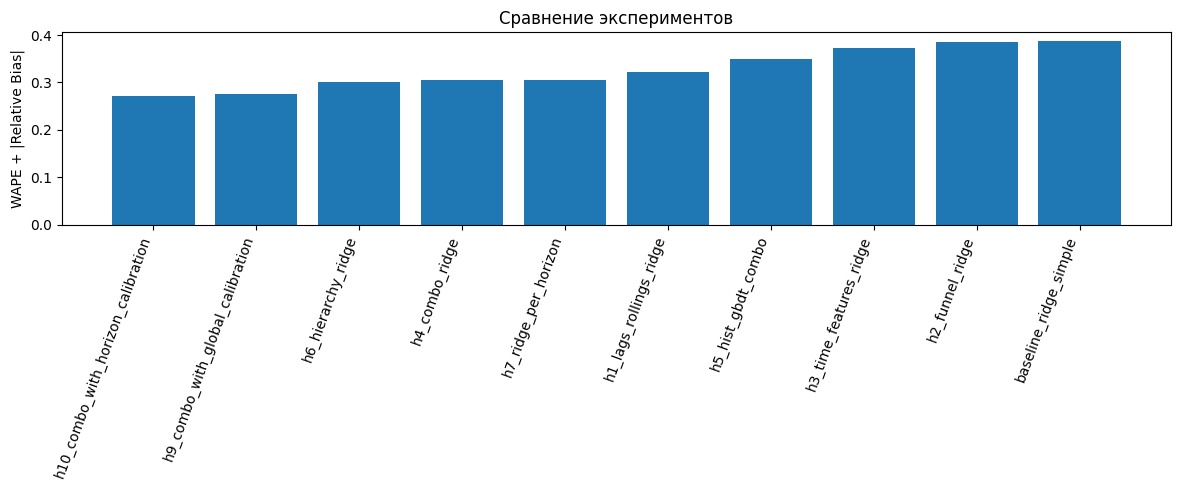

In [29]:

all_results = [baseline_result]

for name in ["h1_result","h2_result","h3_result","h4_result","h5_result","h6_result","h7_result","h9_result","h10_result"]:
    if name in globals():
        all_results.append(globals()[name])

if "h8_result" in globals():
    all_results.append(h8_result)

summary_rows = []
for res in all_results:
    score = res["metrics"].query("horizon == 'all'")["metric"].iloc[0]
    summary_rows.append({"experiment": res["name"], "score_all": score})

summary_df = pd.DataFrame(summary_rows).sort_values("score_all")
display(summary_df)

plt.figure(figsize=(12, 5))
plt.bar(summary_df["experiment"], summary_df["score_all"])
plt.xticks(rotation=70, ha="right")
plt.ylabel("WAPE + |Relative Bias|")
plt.title("Сравнение экспериментов")
plt.tight_layout()
plt.show()

In [40]:
import joblib
from pathlib import Path

# Создаём папку для моделей
MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(exist_ok=True)

saved_models = []

for res in all_results:
    exp_name = res["name"]
    print(f"💾 Сохраняем модель: {exp_name}")
    
    # Случай 1: одна модель на все горизонты (multioutput)
    if "model" in res:
        model_path = MODEL_DIR / f"{exp_name}_model.pkl"
        joblib.dump(res["model"], model_path)
        saved_models.append({
            "experiment": exp_name,
            "path": str(model_path),
            "type": "multioutput"
        })
        print(f"   ✓ Saved: {model_path}")
    
    # Случай 2: отдельная модель на каждый горизонт (per_horizon)
    elif "models" in res:
        horizon_dir = MODEL_DIR / f"{exp_name}_per_horizon"
        horizon_dir.mkdir(exist_ok=True)
        
        for horizon, model in res["models"].items():
            model_path = horizon_dir / f"{horizon}_model.pkl"
            joblib.dump(model, model_path)
        
        # Сохраняем метаданные
        meta_path = horizon_dir / "metadata.json"
        import json
        with open(meta_path, "w") as f:
            json.dump({
                "experiment": exp_name,
                "horizons": list(res["models"].keys()),
                "feature_cols": res.get("feature_cols", []),
                "calibration": {
                    k: v for k, v in res.items() 
                    if "calibration" in k
                }
            }, f, indent=2, default=str)
        
        saved_models.append({
            "experiment": exp_name,
            "path": str(horizon_dir),
            "type": "per_horizon",
            "n_horizons": len(res["models"])
        })
        print(f"   ✓ Saved {len(res['models'])} horizon models to {horizon_dir}")
    
    else:
        print(f"   ⚠ No model found in result for {exp_name}")

# Сохраняем сводку по всем моделям
import pandas as pd
summary = pd.DataFrame(saved_models)
summary.to_csv(MODEL_DIR / "models_registry.csv", index=False)
print(f"\n📋 Registry saved: {MODEL_DIR / 'models_registry.csv'}")
display(summary)

💾 Сохраняем модель: baseline_ridge_simple
   ✓ Saved: saved_models\baseline_ridge_simple_model.pkl
💾 Сохраняем модель: h1_lags_rollings_ridge
   ✓ Saved: saved_models\h1_lags_rollings_ridge_model.pkl
💾 Сохраняем модель: h2_funnel_ridge
   ✓ Saved: saved_models\h2_funnel_ridge_model.pkl
💾 Сохраняем модель: h3_time_features_ridge
   ✓ Saved: saved_models\h3_time_features_ridge_model.pkl
💾 Сохраняем модель: h4_combo_ridge
   ✓ Saved: saved_models\h4_combo_ridge_model.pkl
💾 Сохраняем модель: h5_hist_gbdt_combo
   ✓ Saved: saved_models\h5_hist_gbdt_combo_model.pkl
💾 Сохраняем модель: h6_hierarchy_ridge
   ✓ Saved: saved_models\h6_hierarchy_ridge_model.pkl
💾 Сохраняем модель: h7_ridge_per_horizon
   ✓ Saved 10 horizon models to saved_models\h7_ridge_per_horizon_per_horizon
💾 Сохраняем модель: h9_combo_with_global_calibration
   ✓ Saved: saved_models\h9_combo_with_global_calibration_model.pkl
💾 Сохраняем модель: h10_combo_with_horizon_calibration
   ✓ Saved: saved_models\h10_combo_with_horizo

,experiment,path,type,n_horizons
0,baseline_ridge_simple,saved_models\baseline_ridge_simple_model.pkl,multioutput,NaN
1,h1_lags_rollings_ridge,saved_models\h1_lags_rollings_ridge_model.pkl,multioutput,NaN
2,h2_funnel_ridge,saved_models\h2_funnel_ridge_model.pkl,multioutput,NaN
3,h3_time_features_ridge,saved_models\h3_time_features_ridge_model.pkl,multioutput,NaN
4,h4_combo_ridge,saved_models\h4_combo_ridge_model.pkl,multioutput,NaN
5,h5_hist_gbdt_combo,saved_models\h5_hist_gbdt_combo_model.pkl,multioutput,NaN
6,h6_hierarchy_ridge,saved_models\h6_hierarchy_ridge_model.pkl,multioutput,NaN
7,h7_ridge_per_horizon,saved_models\h7_ridge_per_horizon_per_horizon,per_horizon,10.0
8,h9_combo_with_global_calibration,saved_models\h9_combo_with_global_calibration_...,multioutput,NaN
9,h10_combo_with_horizon_calibration,saved_models\h10_combo_with_horizon_calibratio...,multioutput,NaN


## 16. Rolling validation для лучших гипотез

In [30]:

def run_rolling_validation(base_df: pd.DataFrame, exp_cfg: ExperimentConfig, n_folds: int = 3) -> pd.DataFrame:
    feat_df = build_feature_table(base_df, exp_cfg.feature_cfg).dropna().copy()
    folds = make_time_folds(feat_df, n_folds=n_folds)

    rows = []
    for i, (fit_df, valid_df) in enumerate(folds, start=1):
        if exp_cfg.max_rows is not None and len(fit_df) > exp_cfg.max_rows:
            fit_df = fit_df.sample(exp_cfg.max_rows, random_state=RANDOM_STATE)

        X_fit, y_fit, feature_cols = prepare_xy(fit_df)
        X_valid, y_valid, _ = prepare_xy(valid_df)

        if exp_cfg.train_mode == "multioutput":
            model = build_model_for_experiment(exp_cfg.model_kind, feature_cols, X_fit)
            pred_valid, _ = fit_predict_multioutput(model, X_fit, y_fit, X_valid)
        else:
            if exp_cfg.model_kind == "catboost_per_horizon":
                cat_features = [c for c in X_fit.columns if c.endswith("_id") or str(X_fit[c].dtype) == "object"]
                pred_valid, _ = fit_predict_per_horizon(make_catboost_single_model, X_fit, y_fit, X_valid, cat_features)
            elif exp_cfg.model_kind == "ridge_per_horizon":
                def _factory():
                    return make_ridge_model(feature_cols, X_fit)
                pred_valid, _ = fit_predict_per_horizon(_factory, X_fit, y_fit, X_valid)
            else:
                raise ValueError("train_mode/per_horizon не поддержан для этой модели.")

        if exp_cfg.use_global_calibration:
            pred_valid, _ = calibrate_global_scale(y_valid, pred_valid)
        if exp_cfg.use_horizon_calibration:
            pred_valid, _ = calibrate_per_horizon(y_valid, pred_valid)

        score = metric.calculate(y_valid.values, pred_valid.values)
        rows.append({
            "experiment": exp_cfg.name,
            "fold": i,
            "score": score,
            "fit_rows": len(fit_df),
            "valid_rows": len(valid_df),
        })
    return pd.DataFrame(rows)

# Пример: rolling validation для лучшей гипотезы
best_exp_cfg = h10_exp if "h10_exp" in globals() else h4_exp
rolling_scores = run_rolling_validation(supervised_df, best_exp_cfg, n_folds=3)
display(rolling_scores)
display(rolling_scores.groupby("experiment", as_index=False)["score"].agg(["mean", "std"]).reset_index())

,experiment,fold,score,fit_rows,valid_rows
0,h10_combo_with_horizon_calibration,1,0.287581,2377000,1943000
1,h10_combo_with_horizon_calibration,2,0.280148,3025000,1295000
2,h10_combo_with_horizon_calibration,3,0.271525,3673000,647000


,index,experiment,mean,std
0,0,h10_combo_with_horizon_calibration,0.279751,0.008036


## 17. Ансамбль лучших моделей

In [41]:

def blend_predictions(preds_with_weights: List[Tuple[pd.DataFrame, float]]) -> pd.DataFrame:
    total_weight = sum(w for _, w in preds_with_weights)
    out = None
    for pred, w in preds_with_weights:
        cur = pred * w
        out = cur if out is None else out.add(cur, fill_value=0.0)
    return out / total_weight

blend_candidates = []
for name, weight in [("h4_result", 1.0), ("h9_result", 1.0), ("h6_result", 1.0), ("h10_result", 1.25)]:
    if name in globals():
        blend_candidates.append((globals()[name]["pred_valid"], weight))

if blend_candidates:
    blend_pred = blend_predictions(blend_candidates)
    blend_score = evaluate_predictions(baseline_result["y_valid"], blend_pred, prefix="blend")
    display(blend_score)
else:
    print("Сначала запусти несколько гипотез, чтобы собрать ансамбль.")

,experiment,horizon,metric
0,blend,all,0.913434
1,blend,target_step_1,0.937278
2,blend,target_step_2,0.923711
3,blend,target_step_3,0.913255
4,blend,target_step_4,0.905420
5,blend,target_step_5,0.905578
6,blend,target_step_6,0.906236
7,blend,target_step_7,0.908293
8,blend,target_step_8,0.908630
9,blend,target_step_9,0.911539


## 18. Перевод прогноза в количество машин
Это уже слой бизнес-логики для командного трека.

In [42]:

def convert_volume_to_cars(
    forecast_df: pd.DataFrame,
    volume_col: str = "y_pred",
    capacity_per_car: float = 33.0,
    safety_coef: float = 1.05,
    min_cars: int = 0,
) -> pd.DataFrame:
    out = forecast_df.copy()
    adjusted_volume = np.maximum(out[volume_col], 0) * safety_coef
    out["cars_needed"] = np.maximum(np.ceil(adjusted_volume / capacity_per_car), min_cars).astype(int)
    return out

demo_forecast = pd.DataFrame({
    "route_id": [1, 1, 2],
    "timestamp": pd.to_datetime(["2026-01-01 10:00:00", "2026-01-01 10:30:00", "2026-01-01 10:00:00"]),
    "y_pred": [17.5, 40.2, 68.4],
})

display(convert_volume_to_cars(demo_forecast, capacity_per_car=33, safety_coef=1.10))

,route_id,timestamp,y_pred,cars_needed
0,1,2026-01-01 10:00:00,17.5,1
1,1,2026-01-01 10:30:00,40.2,2
2,2,2026-01-01 10:00:00,68.4,3


## 19. Шаблон инференса для лучшей модели
Ниже — заготовка под baseline-логику: обучить на train и сделать прогноз на тестовый горизонт.

In [33]:

def forecast_from_last_fact(best_result: Dict[str, object], base_train_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    inference_ts = base_train_df[TIME_COL].max()

    # нужно построить признаки в том же стиле, что и для обучения
    # пример ниже — для h10, но можно подставить любой exp_cfg
    exp_map = {
        "baseline_ridge_simple": baseline_exp,
    }
    for nm in ["h1_exp","h2_exp","h3_exp","h4_exp","h5_exp","h6_exp","h7_exp","h8_exp","h9_exp","h10_exp"]:
        if nm in globals():
            exp_map[globals()[nm].name] = globals()[nm]

    exp_cfg = exp_map[best_result["name"]]

    # ВАЖНО: признаки со сдвигами считаются на всей train-истории, затем берется последний timestamp.
    # Нельзя делать dropna() по всей строке: на последнем timestamp future-target'ы пустые по определению.
    feat_train = build_feature_table(make_future_targets(base_train_df), exp_cfg.feature_cfg)
    feat_latest = feat_train[feat_train[TIME_COL] == inference_ts].copy()
    feature_cols = best_result["feature_cols"]
    feat_latest = feat_latest.dropna(subset=feature_cols).copy()

    if feat_latest.empty:
        forecast = pd.DataFrame(columns=[ROUTE_COL, TIME_COL, "y_pred"])
    else:
        X_test = feat_latest[feature_cols].copy()

        if "model" in best_result:
            pred = best_result["model"].predict(X_test)
            pred = pd.DataFrame(np.clip(pred, 0, None), columns=FUTURE_TARGET_COLS, index=X_test.index)
        elif "models" in best_result:
            pred = pd.DataFrame(index=X_test.index)
            for col, model in best_result["models"].items():
                pred[col] = np.clip(model.predict(X_test), 0, None)
        else:
            raise ValueError("В result не найдено обученной модели.")

        if "global_calibration" in best_result:
            pred = pred * best_result["global_calibration"]["best_k"]

        if "horizon_calibration" in best_result:
            for col, info in best_result["horizon_calibration"].items():
                pred[col] = pred[col] * info["best_k"]

        pred[ROUTE_COL] = feat_latest[ROUTE_COL].values
        forecast = pred.melt(
            id_vars=ROUTE_COL,
            value_vars=FUTURE_TARGET_COLS,
            var_name="step",
            value_name="y_pred"
        )
        forecast["step_num"] = forecast["step"].str.extract(r"(\d+)").astype(int)
        forecast[TIME_COL] = inference_ts + pd.to_timedelta(forecast["step_num"] * STEP_MINUTES, unit="m")
        forecast = forecast[[ROUTE_COL, TIME_COL, "y_pred"]].sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)

    if test_df is not None and ID_COL in test_df.columns:
        submission = test_df.merge(forecast, on=[ROUTE_COL, TIME_COL], how="left")[[ID_COL, "y_pred"]]
        submission["y_pred"] = submission["y_pred"].fillna(0.0).clip(lower=0)
        return submission
    return forecast

# пример:
# best_result = h10_result
# submission = forecast_from_last_fact(best_result, train_df, test_df)
# submission.to_csv("submission_best.csv", index=False)
# display(submission.head())

## 20. Журнал экспериментов

In [34]:

experiment_log = pd.DataFrame([
    {
        "experiment": res["name"],
        "score_all": res["metrics"].query("horizon == 'all'")["metric"].iloc[0],
        "n_features": len(res["feature_cols"]),
        "fit_rows": len(res["X_fit"]),
        "valid_rows": len(res["X_valid"]),
    }
    for res in all_results
]).sort_values("score_all")

display(experiment_log)

,experiment,score_all,n_features,fit_rows,valid_rows
9,h10_combo_with_horizon_calibration,0.272330,213,3456000,864000
8,h9_combo_with_global_calibration,0.275099,213,3456000,864000
6,h6_hierarchy_ridge,0.301379,63,3465000,866000
4,h4_combo_ridge,0.305087,204,3456000,864000
7,h7_ridge_per_horizon,0.305087,204,3456000,864000
1,h1_lags_rollings_ridge,0.321037,163,3456000,864000
5,h5_hist_gbdt_combo,0.349418,207,300000,864000
3,h3_time_features_ridge,0.373420,23,3466000,866000
2,h2_funnel_ridge,0.384742,38,3466000,866000
0,baseline_ridge_simple,0.386443,10,3466000,866000


In [43]:

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.base import clone

SUBMIT_DIR = Path("submissions_all_hypotheses")
SUBMIT_DIR.mkdir(exist_ok=True)

def get_experiment_registry():
    registry = {}
    for nm in ["baseline_exp","h1_exp","h2_exp","h3_exp","h4_exp","h5_exp","h6_exp","h7_exp","h8_exp","h9_exp","h10_exp"]:
        if nm in globals():
            exp_cfg = globals()[nm]
            registry[exp_cfg.name] = exp_cfg
    return registry

def get_local_results_registry():
    registry = {}
    for nm in ["baseline_result","h1_result","h2_result","h3_result","h4_result","h5_result","h6_result","h7_result","h8_result","h9_result","h10_result"]:
        if nm in globals():
            res = globals()[nm]
            registry[res["name"]] = res
    return registry

def fit_full_experiment(base_df: pd.DataFrame, exp_cfg: ExperimentConfig) -> Dict[str, object]:
    feat_df = build_feature_table(base_df, exp_cfg.feature_cfg).dropna().copy()

    if exp_cfg.max_rows is not None and len(feat_df) > exp_cfg.max_rows:
        fit_df = feat_df.sample(exp_cfg.max_rows, random_state=RANDOM_STATE)
    else:
        fit_df = feat_df

    X_fit, y_fit, feature_cols = prepare_xy(fit_df)

    if exp_cfg.train_mode == "multioutput":
        model = build_model_for_experiment(exp_cfg.model_kind, feature_cols, X_fit)
        model = clone(model)
        model.fit(X_fit, y_fit)
        fitted = {"model": model}
    elif exp_cfg.train_mode == "per_horizon":
        if exp_cfg.model_kind == "catboost_per_horizon":
            cat_features = [c for c in X_fit.columns if c.endswith("_id") or str(X_fit[c].dtype) == "object"]
            _, models = fit_predict_per_horizon(make_catboost_single_model, X_fit, y_fit, X_fit.iloc[:1], cat_features)
        elif exp_cfg.model_kind == "ridge_per_horizon":
            def _factory():
                return make_ridge_model(feature_cols, X_fit)
            _, models = fit_predict_per_horizon(_factory, X_fit, y_fit, X_fit.iloc[:1])
        else:
            raise ValueError(f"Неизвестный per_horizon model_kind: {exp_cfg.model_kind}")
        fitted = {"models": models}
    else:
        raise ValueError(f"Неизвестный train_mode: {exp_cfg.train_mode}")

    result = {
        "name": exp_cfg.name,
        "feature_cols": feature_cols,
        "X_fit_full": X_fit,
        "y_fit_full": y_fit,
        **fitted
    }

    local_results = get_local_results_registry()
    if exp_cfg.name in local_results:
        local_res = local_results[exp_cfg.name]
        if "global_calibration" in local_res:
            result["global_calibration"] = local_res["global_calibration"]
        if "horizon_calibration" in local_res:
            result["horizon_calibration"] = local_res["horizon_calibration"]

    return result

def build_latest_features_for_inference(
    base_train_df: pd.DataFrame,
    exp_cfg: ExperimentConfig,
    feature_cols: Optional[List[str]] = None,
) -> pd.DataFrame:
    inference_ts = base_train_df[TIME_COL].max()
    feat_train = build_feature_table(make_future_targets(base_train_df), exp_cfg.feature_cfg)
    feat_latest = feat_train[feat_train[TIME_COL] == inference_ts].copy()
    if feature_cols is not None:
        missing_cols = [col for col in feature_cols if col not in feat_latest.columns]
        if missing_cols:
            raise ValueError(f"В инференсе не найдены признаки: {missing_cols[:10]}")
        feat_latest = feat_latest.dropna(subset=feature_cols).copy()
    return feat_latest

def predict_test_from_full_model(full_result: Dict[str, object], exp_cfg: ExperimentConfig, base_train_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    inference_ts = base_train_df[TIME_COL].max()
    feature_cols = full_result["feature_cols"]
    feat_latest = build_latest_features_for_inference(base_train_df, exp_cfg, feature_cols)

    if feat_latest.empty:
        forecast = pd.DataFrame(columns=[ROUTE_COL, TIME_COL, "y_pred"])
    else:
        X_test = feat_latest[feature_cols].copy()

        if "model" in full_result:
            pred = full_result["model"].predict(X_test)
            pred = pd.DataFrame(np.clip(pred, 0, None), columns=FUTURE_TARGET_COLS, index=X_test.index)
        elif "models" in full_result:
            pred = pd.DataFrame(index=X_test.index)
            for col, model in full_result["models"].items():
                pred[col] = np.clip(model.predict(X_test), 0, None)
        else:
            raise ValueError("В full_result не найдено обученной модели.")

        if "global_calibration" in full_result:
            pred = pred * full_result["global_calibration"]["best_k"]

        if "horizon_calibration" in full_result:
            for col, info in full_result["horizon_calibration"].items():
                pred[col] = pred[col] * info["best_k"]

        pred[ROUTE_COL] = feat_latest[ROUTE_COL].values
        forecast = pred.melt(
            id_vars=ROUTE_COL,
            value_vars=FUTURE_TARGET_COLS,
            var_name="step",
            value_name="y_pred"
        )
        forecast["step_num"] = forecast["step"].str.extract(r"(\d+)").astype(int)
        forecast[TIME_COL] = inference_ts + pd.to_timedelta(forecast["step_num"] * STEP_MINUTES, unit="m")
        forecast = forecast[[ROUTE_COL, TIME_COL, "y_pred"]].sort_values([ROUTE_COL, TIME_COL]).reset_index(drop=True)

    if test_df is None:
        return forecast

    required_cols = [ROUTE_COL, TIME_COL]
    if not all(col in test_df.columns for col in required_cols):
        raise ValueError(f"В test_df должны быть колонки {required_cols}")

    merged = test_df.merge(forecast, on=[ROUTE_COL, TIME_COL], how="left")
    if ID_COL in merged.columns:
        submission = merged[[ID_COL, "y_pred"]].copy()
    else:
        submission = merged[[ROUTE_COL, TIME_COL, "y_pred"]].copy()
    submission["y_pred"] = submission["y_pred"].fillna(0.0).clip(lower=0)
    return submission

exp_registry = get_experiment_registry()
local_registry = get_local_results_registry()

print("Эксперименты в реестре:", list(exp_registry.keys()))
print("Локальные результаты:", list(local_registry.keys())[:5], "... всего", len(local_registry))


Эксперименты в реестре: ['baseline_ridge_simple', 'h1_lags_rollings_ridge', 'h2_funnel_ridge', 'h3_time_features_ridge', 'h4_combo_ridge', 'h5_hist_gbdt_combo', 'h6_hierarchy_ridge', 'h7_ridge_per_horizon', 'h9_combo_with_global_calibration', 'h10_combo_with_horizon_calibration']
Локальные результаты: ['baseline_ridge_simple', 'h1_lags_rollings_ridge', 'h2_funnel_ridge', 'h3_time_features_ridge', 'h4_combo_ridge'] ... всего 10


In [46]:
# === Отладка: проверка построения признаков ===

print(f"train_df shape: {train_df.shape}")
print(f"test_df shape: {test_df.shape}")
print(f"train_df timestamp range: {train_df[TIME_COL].min()} -> {train_df[TIME_COL].max()}")
print(f"Columns in train_df: {list(train_df.columns)}")

# Проверка для одного эксперимента
debug_exp = exp_registry["h4_combo_ridge"]  # или любой другой

# 1. Создаем целевые переменные
train_with_targets = make_future_targets(train_df)
print(f"\nAfter make_future_targets: {train_with_targets.shape}")
print(f"Target columns created: {[c for c in train_with_targets.columns if 'target_step' in c][:5]}")

# 2. Строим признаки
debug_feat = build_feature_table(train_with_targets, debug_exp.feature_cfg)
print(f"\nAfter build_feature_table: {debug_feat.shape}")

# 3. Проверяем, какие признаки были добавлены
all_cols = set(debug_feat.columns)
base_cols = set(train_df.columns) | set(FUTURE_TARGET_COLS) | {TIME_COL, ROUTE_COL, OFFICE_COL}
new_features = list(all_cols - base_cols)
print(f"New features added: {len(new_features)}")
print(f"Sample new features: {new_features[:10]}")

# 4. Проверяем наличие лагов и роллингов
lag_cols = [c for c in debug_feat.columns if 'lag' in c.lower()]
roll_cols = [c for c in debug_feat.columns if 'roll' in c.lower()]
print(f"\nLag columns: {len(lag_cols)}")
if lag_cols:
    print(f"  Examples: {lag_cols[:5]}")
print(f"Rolling columns: {len(roll_cols)}")
if roll_cols:
    print(f"  Examples: {roll_cols[:5]}")

# 5. Корректная фильтрация NaN для лагов
# Важно: dropna(subset=[]) удаляет строки, где ЛЮБОЙ столбец имеет NaN!
if debug_exp.feature_cfg.use_status_lags or debug_exp.feature_cfg.use_target_lags:
    cols_to_check = [c for c in debug_feat.columns if 'lag' in c.lower()]
else:
    cols_to_check = []

if cols_to_check:
    debug_valid = debug_feat.dropna(subset=cols_to_check)
    print(f"\nAfter dropna on lag columns ({len(cols_to_check)} cols): {debug_valid.shape}")
else:
    # Если нет лагов, просто удаляем строки с любыми NaN в фичах
    feature_cols = [c for c in debug_feat.columns if c not in {TIME_COL, ROUTE_COL, OFFICE_COL, *FUTURE_TARGET_COLS}]
    debug_valid = debug_feat.dropna(subset=feature_cols)
    print(f"\nAfter dropna on all features: {debug_valid.shape}")

# 6. Проверка временного диапазона
if len(debug_valid) > 0:
    print(f"First valid timestamp: {debug_valid[TIME_COL].min()}")
    print(f"Last valid timestamp: {debug_valid[TIME_COL].max()}")
    
    # Проверка на утечку данных: последние строки не должны иметь целевых переменных
    last_rows = debug_valid.nlargest(5, TIME_COL)
    print(f"\nLast 5 rows target values (should have NaNs for future steps):")
    print(last_rows[[TIME_COL, ROUTE_COL] + FUTURE_TARGET_COLS[:3]].head())
else:
    print("\n⚠️ WARNING: All rows dropped! Check your feature engineering logic.")
    print("Possible causes:")
    print("  - Too many lag steps for available history")
    print("  - Rolling windows larger than group size")
    print("  - Incorrect groupby on route_id")

train_df shape: (4342000, 12)
test_df shape: (10000, 3)
train_df timestamp range: 2025-03-01 00:00:00 -> 2025-05-30 10:30:00
Columns in train_df: ['office_from_id', 'route_id', 'timestamp', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8', 'target_2h']

After make_future_targets: (4342000, 22)
Target columns created: ['target_step_1', 'target_step_2', 'target_step_3', 'target_step_4', 'target_step_5']

After build_feature_table: (4342000, 216)
New features added: 194
Sample new features: ['target_2h_rollmax_8', 'status_8_rollstd_8', 'status_4_rollmax_2', 'status_mean', 'status_6_div_status_5', 'status_7_rollmax_2', 'status_4_rollstd_2', 'status_3_lag_4', 'status_1_rollmax_4', 'status_7_rollmean_4']

Lag columns: 45
  Examples: ['status_1_lag_1', 'status_1_lag_2', 'status_1_lag_4', 'status_1_lag_6', 'status_1_lag_12']
Rolling columns: 108
  Examples: ['status_1_rollmean_2', 'status_1_rollstd_2', 'status_1_rollmax_2', 'status_1_rollmean_4', '

In [44]:

# Выбираем гипотезы для full-train retrain и submission.
# baseline можно оставить отдельно, но обычно в сабмит отправляют именно гипотезы h1..h10.
submit_experiments = [name for name in exp_registry.keys() if name != "baseline_ridge_simple"]

full_train_results = {}
submission_registry = []
oof_leaderboard_rows = []

for exp_name in submit_experiments:
    exp_cfg = exp_registry[exp_name]
    print(f"\n=== Full-train retrain: {exp_name} ===")
    full_res = fit_full_experiment(make_future_targets(train_df), exp_cfg)
    full_train_results[exp_name] = full_res

    submission_df = predict_test_from_full_model(full_res, exp_cfg, train_df, test_df)
    sub_path = SUBMIT_DIR / f"submission_{exp_name}.csv"
    submission_df.to_csv(sub_path, index=False)

    local_score = None
    if exp_name in local_registry:
        local_score = local_registry[exp_name]["metrics"].query("horizon == 'all'")["metric"].iloc[0]
        oof_leaderboard_rows.append({"experiment": exp_name, "local_score": local_score})

    submission_registry.append({
        "experiment": exp_name,
        "submission_path": str(sub_path),
        "rows": len(submission_df),
        "local_score": local_score,
    })
    print(f"saved -> {sub_path}")

submission_registry_df = pd.DataFrame(submission_registry).sort_values(["local_score", "experiment"], na_position="last")
submission_registry_df.to_csv(SUBMIT_DIR / "submission_registry.csv", index=False)

display(submission_registry_df)



=== Full-train retrain: h1_lags_rollings_ridge ===


ValueError: Found array with 0 sample(s) (shape=(0, 161)) while a minimum of 1 is required by SimpleImputer.

In [ ]:

def compute_blend_weights_from_local_scores(local_scores_df: pd.DataFrame, power: float = 2.0) -> pd.DataFrame:
    df = local_scores_df.copy().dropna()
    df["weight_raw"] = 1.0 / np.maximum(df["local_score"], 1e-9) ** power
    df["weight"] = df["weight_raw"] / df["weight_raw"].sum()
    return df.sort_values("local_score")

blend_weights_df = compute_blend_weights_from_local_scores(pd.DataFrame(oof_leaderboard_rows), power=2.0)
display(blend_weights_df)

forecast_parts = []
for _, row in blend_weights_df.iterrows():
    exp_name = row["experiment"]
    weight = row["weight"]
    sub_path = SUBMIT_DIR / f"submission_{exp_name}.csv"
    sub_df = pd.read_csv(sub_path)
    sub_df = sub_df.rename(columns={"y_pred": f"pred_{exp_name}"})
    forecast_parts.append((exp_name, weight, sub_df))

ensemble_df = None
for exp_name, weight, sub_df in forecast_parts:
    cur = sub_df.copy()
    pred_col = f"pred_{exp_name}"
    if ID_COL in cur.columns:
        merge_keys = [ID_COL]
    else:
        merge_keys = [ROUTE_COL, TIME_COL]
    cur = cur[merge_keys + [pred_col]]

    if ensemble_df is None:
        ensemble_df = cur.copy()
        ensemble_df["y_pred"] = cur[pred_col] * weight
    else:
        ensemble_df = ensemble_df.merge(cur, on=merge_keys, how="inner")
        ensemble_df["y_pred"] += ensemble_df[pred_col] * weight

if ID_COL in ensemble_df.columns:
    ensemble_submission = ensemble_df[[ID_COL, "y_pred"]].copy()
else:
    ensemble_submission = ensemble_df[[ROUTE_COL, TIME_COL, "y_pred"]].copy()

ensemble_submission["y_pred"] = ensemble_submission["y_pred"].fillna(0.0).clip(lower=0)
ensemble_path = SUBMIT_DIR / "submission_ensemble.csv"
ensemble_submission.to_csv(ensemble_path, index=False)

print("saved ->", ensemble_path)
display(ensemble_submission.head())


In [ ]:

final_registry = submission_registry_df.copy()
final_registry["is_ensemble"] = False
ensemble_row = pd.DataFrame([{
    "experiment": "ensemble_weighted_by_local_score",
    "submission_path": str(SUBMIT_DIR / "submission_ensemble.csv"),
    "rows": len(ensemble_submission),
    "local_score": np.nan,
    "is_ensemble": True,
}])
final_registry = pd.concat([final_registry, ensemble_row], ignore_index=True)
final_registry.to_csv(SUBMIT_DIR / "submission_registry_with_ensemble.csv", index=False)

print("Все сабмиты сохранены в:", SUBMIT_DIR.resolve())
display(final_registry)
